# Predicting Cancellations in Hotel Reservations (Phase 1)

Author: Jialun Darren Huang

## Table of Contents
1. [Import Libraries](#lib_func)
2. [Introduction](#intro)<br>
    2.1. [Load the Dataset](#load_data)<br>
    2.2. [Dataset Source](#data_source)<br>
    2.3. [Understanding the Data](#understand_data)<br>
        2.3.1. [Dataset Details](#data_details)<br>
        2.3.2. [Dataset Features](#data_features)<br>
        2.3.3. [Target Feature](#target_feature)<br>
3. [Goals and Objectives](#goal)
4. [Methodology Overview](#method)
5. [Data Cleaning and Preprocessing](#data_clean_preproc)
6. [Exploratory Data Analysis](#eda)
7. [Summary and Conclusion](#sum_con)
8. [References](#ref)

---

## <a id = "lib_func">1. Import Libraries<a/>

We load the modules that we will use throughout the report.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

## <a id = "intro">2. Introduction<a/>

### <a id = "load_data">2.1. Load the Dataset<a/>

#### <a id = "data_source">2.2. Dataset Source<a/>

The Hotel Reservations Classification dataset used in this report was sourced from Kaggle (Raza, 2021). This dataset contains information on hotel bookings, including details such as guest demographics, booking behaviours and booking outcomes (whether the reservation was cancelled or not) between the years 2017 and 2018.

Dataset Link: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

In [2]:
csv_filename = "hotel_reservations_data.csv"
df = pd.read_csv(csv_filename)

---

### <a id = "understand_data">2.3. Understanding the Data<a/>

#### <a id = "data_details">2.3.1. Dataset Details<a/>

This dataset contains information about hotel bookings, specifically focusing on factors that may influence booking outcomes, such as whether the booking was cancelled or not. It includes features such as the number of guests (by adults and children), number of nights stayed (by weekend and weekdays), types of meal and room planned for the reservation, if the guest is a new customer or if the guest requires car space, the number of dates between the booking made and check-in date, and the average price of each room, as a booking can have multiple hotel rooms reserved. These features and more that will be discussed later in the report are used to analyse if the guests went through or cancelled the bookings.

The dataset has a total of 36275 observations and 19 features.

We display 10 randomly sampled rows from this dataset

In [3]:
df.sample(n = 10)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
30624,INN30625,2,0,2,1,Meal Plan 1,0,Room_Type 1,41,2018,3,13,Corporate,0,0,0,85.67,0,Not_Canceled
4285,INN04286,2,0,1,1,Not Selected,0,Room_Type 1,15,2018,1,23,Online,0,0,0,76.50,0,Not_Canceled
10909,INN10910,2,0,0,2,Not Selected,0,Room_Type 1,131,2018,8,5,Online,0,0,0,76.23,2,Not_Canceled
27489,INN27490,2,0,0,4,Not Selected,0,Room_Type 1,3,2018,3,8,Online,0,0,0,93.00,1,Not_Canceled
14527,INN14528,2,0,1,0,Meal Plan 1,0,Room_Type 1,13,2018,3,20,Offline,0,0,0,85.00,1,Not_Canceled
29211,INN29212,2,0,1,2,Meal Plan 1,0,Room_Type 1,62,2018,11,21,Offline,0,0,0,75.00,0,Not_Canceled
29366,INN29367,1,0,2,1,Meal Plan 1,0,Room_Type 1,29,2018,3,5,Offline,0,0,0,86.00,1,Not_Canceled
10798,INN10799,2,0,1,3,Not Selected,0,Room_Type 1,94,2018,11,3,Online,0,0,0,79.20,1,Not_Canceled
23259,INN23260,2,0,0,3,Meal Plan 1,0,Room_Type 2,157,2018,8,31,Online,0,0,0,108.66,0,Canceled
12578,INN12579,1,0,0,3,Meal Plan 1,0,Room_Type 1,15,2018,2,18,Offline,0,0,0,86.00,0,Not_Canceled


In [4]:
df.shape

(36275, 19)

There are a total of 36275 observations and 19 features in the original dataset.

#### <a id = "data_features">2.3.2. Dataset Features<a/>

We will be removing the Date features from the dataset - `arrival_year`, `arrival_month` and `arrival_date`.  

1) Date features do not carry much information
- The duration of a guest's stay can be seen in the combined features `no_of_weekend_nights` and `no_of_week_nights`.
- These features explain how long the stay is, regardless of the arrival dates.
- For example, a booking from 1st January 2025 (Wednesday) to 3rd January 2025 (Friday) and 8th January 2025 (Wednesday) to 10th January 2025 (Friday) both with 2 weekday nights. They should have similar hotel operations, despite having different arrival dates.

2) Limited use for modelling
- Even though modelling is not in phase 1, it is essential to keep a note of model assessment during the early stages of data collection.
- Including exact dates introduces unnecessary complexity and can lead to porr generalisation
- Models may pick up on such features for correlation. For example, booking cancellations may appear higher in certain days, but is not a reason why bookings are cancelled.
- A better option for generalising time-based features could be including peak seasons, to better understand peak and off-peak booking trends.

3) Other similar features have better booking behaviour representation
- Features such as `no_of_weekend_nights`, `no_of_week_nights` are able to represent the length of stay and potentially the cost of stay `avg_price_per_room`
- `lead_time` reflects the number of days between the booking and arrival
- These similar features regarding dates are capable on explaining booking behaviour more, unlike a specific given date

While the Date features may seemed useful initially, they offer little value and can affect model performance negatively. Features that show the total stay duration and lead time can offer more insights to a customer's booking behaviour.

By removing the raw date fields `arrival_year`, `arrival_month` and `arrival_date`, we simplify the dataset, reduce the risk of overfitting during modelling, and improve overall data clarity and interpretability, which allows a more robust and generalised analysis.

|Feature Name|Data Type|Units|Description|
|---|---|---|---|
|Booking_ID|Nominal Categorical|NA|Unique identifier number for each reservation|
|no_of_adults|Discrete Numerical|NA|Total number of guest adults in the reservation|
|no_of_children|Discrete Numerical|NA|Total number of guest children in the reservation|
|no_of_weekend_nights|Discrete Numerical|NA|Number of weekend nights (Saturday or Sunday) booked to stay in the hotel|
|no_of_week_nights|Discrete Numerical|NA|Number of weekday nights (Monday to Friday) booked to stay in the hotel|
|type_of_meal_plan|Nominal Categorical|NA|Type of meal plan selected for the reservation<br><br>Meal Plan 1<br>Meal Plan 2<br>Meal Plan 3<br>Not Selected|
|required_car_parking_space|Nominal Categorical|NA|Boolean flag indicating if the guest required a car parking space<br><br>0: No<br>1: Yes|
|room_type_reserved|Nominal Categorical|NA|Type of room booked, the values are ciphered (encoded) by INN Hotels<br><br>Room_Type 1<br>Room_Type 2<br>Room_Type 3<br>Room_Type 4<br>Room_Type 5<br>Room_Type 6<br>Room_Type 7|
|lead_time|Discrete Numerical|NA|Number of days between the date of booking and reservation date|
|market_segment_type|Nominal Categorical|NA|Type of Market Segment<br><br>Aviation<br>Complementary<br>Corporate<br>Offline<br>Online|
|repeated_guest|Nominal Categorical|NA|Boolean flag indicating if the guest a reapeated guest<br><br>0: No<br>1: Yes|
|no_of_previous_cancellations|Discrete Numerical|NA|Number of previous bookings cancelled by the guest prior to the current booking|
|no_of_previous_bookings_not_cancelled|Discrete Numerical|NA|Number of previous bookings not cancelled by the guest prior to the current booking|
|avg_price_per_room|Continuous Numerical|Euro (€)|Average price per day of the reservation (in euros)<br>Note: Prices of the room can vary
|no_of_special_requests|Discrete Numerical|NA|Total number of special requests made by the guest (e.g. high floor, view from the room, etc.)
|booking_status|Nominal Categorical|NA|Boolean flag indicating if the booking was cancelled<br><br>Cancelled<br>Not_Cancelled|

Standardised spelling by changing canceled to cancelled

`no_of_previous_bookings_not_canceled` to `no_of_previous_bookings_not_cancelled`

In [5]:
df = df.rename({"no_of_previous_bookings_not_canceled": "no_of_previous_bookings_not_cancelled"}, axis = 1)

Drop date columns `arrival_year`, `arrival_month`, `arrival_date` from dataset

In [6]:
df = df.drop(["arrival_year", "arrival_month", "arrival_date"], axis = 1)

In [7]:
df.sample(n = 10)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_cancelled,avg_price_per_room,no_of_special_requests,booking_status
9204,INN09205,2,0,1,2,Meal Plan 1,0,Room_Type 4,0,Complementary,0,0,0,0.00,2,Not_Canceled
6691,INN06692,2,0,0,3,Meal Plan 1,0,Room_Type 1,19,Offline,1,1,0,90.00,0,Not_Canceled
17940,INN17941,2,0,1,2,Meal Plan 1,0,Room_Type 1,106,Online,0,0,0,90.00,2,Canceled
4184,INN04185,1,0,2,1,Meal Plan 1,0,Room_Type 1,12,Corporate,0,0,0,66.00,1,Not_Canceled
6481,INN06482,2,0,1,2,Not Selected,0,Room_Type 1,55,Online,0,0,0,116.10,1,Canceled
3019,INN03020,2,0,0,2,Meal Plan 1,0,Room_Type 1,29,Online,0,0,0,86.45,1,Not_Canceled
21205,INN21206,2,0,0,3,Meal Plan 1,0,Room_Type 2,246,Online,0,0,0,81.77,1,Canceled
34876,INN34877,1,0,0,3,Meal Plan 1,0,Room_Type 1,176,Offline,0,0,0,116.10,0,Canceled
15044,INN15045,2,0,2,0,Meal Plan 1,0,Room_Type 1,20,Offline,0,0,0,85.50,1,Not_Canceled
16310,INN16311,2,0,0,3,Meal Plan 1,0,Room_Type 1,259,Offline,0,0,0,90.00,0,Canceled


In [8]:
df.shape

(36275, 16)

There are a total of 36275 observations and 16 features in the dataset.

In [9]:
df.dtypes

Booking_ID                                object
no_of_adults                               int64
no_of_children                             int64
no_of_weekend_nights                       int64
no_of_week_nights                          int64
type_of_meal_plan                         object
required_car_parking_space                 int64
room_type_reserved                        object
lead_time                                  int64
market_segment_type                       object
repeated_guest                             int64
no_of_previous_cancellations               int64
no_of_previous_bookings_not_cancelled      int64
avg_price_per_room                       float64
no_of_special_requests                     int64
booking_status                            object
dtype: object

Pandas sees the following as categories
- Booking_ID
- type_of_meal_plan
- room_type_reserved
- market_segment_type
- booking_status

Note: `required_car_parking_space` and `repeated_guest` are binary categories but are seen as integers (int64) because they are 1s and 0s, indicating True and False values. We can leave them as it is for now as such values would be used in modelling as part of preprocessing categorical features with one hot encoding, but we should always take note that they are not numerical columns.

Pandas sees the following as numerical whole numbers (integers)
- no_of_adults
- no_of_children
- no_of_weekend_nights
- no_of_week_nights
- lead_time
- no_of_previous_cancellations
- no_of_previous_bookings_not_cancelled
- no_of_special_requests

Pandas sees the following as decimal numbers (doubles or floats)
- avg_price_per_room

In [10]:
df.isna().sum()

Booking_ID                               0
no_of_adults                             0
no_of_children                           0
no_of_weekend_nights                     0
no_of_week_nights                        0
type_of_meal_plan                        0
required_car_parking_space               0
room_type_reserved                       0
lead_time                                0
market_segment_type                      0
repeated_guest                           0
no_of_previous_cancellations             0
no_of_previous_bookings_not_cancelled    0
avg_price_per_room                       0
no_of_special_requests                   0
booking_status                           0
dtype: int64

There are no missing or NA values

In [11]:
df.describe(include = "all")

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_cancelled,avg_price_per_room,no_of_special_requests,booking_status
count,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN00001,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,1.844962,0.105279,0.810724,2.204300,NaN,0.030986,NaN,85.232557,NaN,0.025637,0.023349,0.153411,103.423539,0.619655,NaN
std,NaN,0.518715,0.402648,0.870644,1.410905,NaN,0.173281,NaN,85.930817,NaN,0.158053,0.368331,1.754171,35.089424,0.786236,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,0.000000,0.000000,1.000000,NaN,0.000000,NaN,17.000000,NaN,0.000000,0.000000,0.000000,80.300000,0.000000,NaN
50%,NaN,2.000000,0.000000,1.000000,2.000000,NaN,0.000000,NaN,57.000000,NaN,0.000000,0.000000,0.000000,99.450000,0.000000,NaN
75%,NaN,2.000000,0.000000,2.000000,3.000000,NaN,0.000000,NaN,126.000000,NaN,0.000000,0.000000,0.000000,120.000000,1.000000,NaN


Just a general overview, we  will look into this separately for each column during data cleaning.

#### <a id = "target_feature">2.3.3. Target Feature<a/>

The `booking_status` feature represents the outcome of a hotel booking, whether the booking was cancelled or not cancelled by the guest. This binary categorical feature serves as the target for analysis, to help understand the factors influencing booking cancellations.

---

## <a id = "goal">3. Goals and Objectives<a/>

In reecent years, the hospitality industry has increasingly utilised data analytics and machine learning techniques to improve various aspects of hotel business operations, including revenue management, guest satisfaction and resource allocation. A crucial area of focus is the prediction of hotel booking cancellations.

Accurate forecasting of cancellation behaviour is essential for hotels to optimise resources and strategies, better manage room availability, which can ultimately minimise losses. This has led to an expansion in exploring various factors influencing cancellations, as well as the use of machine learning algorithms to predict booking outcomes (in Phase 2).

The main objective of their report is to identify the key features that influence booking outcomes, particularly if bookings are cancelled or not. To achieve this, we begin by checking the cleanliness of the data, followed by analysing the data, using summary statistics and graphical visualisations to uncover patterns and trends related to booking behaviour.

Although the dataset may include multiple bookings from the same guest, we assume that each booking is independent. This assumption helps to simplify the analysis and allows us to treat each booking as a standalone observation. It also reflects a realistic scenario where guests may book on behalf of others, such as for family, friends or colleagues, or make separate bookings for different stays.

---

## <a id = "method">4. Methodology Overview<a/>

This report follows a structured approach to explore and analyse hotel booking data. The methodology is divided into two main phases - Data Cleaning and Preprocessing, and then followed by Exploratory Data Analysis

1. Data Cleaning and Preprocessing

Before analysis, the dataset is cleaned to ensure accuracy and consistency. This involves reviewing several aspects of the data such as:
- Checking for missing or null values
- Identifying and correcting incorrect feature data types
- Detecting inconsistent or invalid values within features
- Ensuring feature names are clear and appropriately formatted

2. Exploratory Data Analysis

Exploratory Data Analysis is conducted to uncover patterns and trends related to booking outcomes. Graph visualisation and summary statistics are used to support the insights in the following areas
- Proportion of Cancelled vs. Non-Cancelled Bookings
- Number of Adults and Children in bookings
- Lead Time on Booking Cancellations
- Number of Stayed Nights (weekday and weekend) on Booking Cancellations
- Average Room Price in relation to whether Guest is a new or repeated Customer, and how that relates to booking cancellations
- Average Room Price based on the Number of Special Requests made by the Guest, and how that relates to booking cancellations

---

## <a id = "data_clean_preproc">5. Data Cleaning and Preprocessing<a/>

To begin, we have to clean the dataset through a process called Data Cleaning and Preprocessing. This includes handling missing values, removing duplicates, fixing inconsistent values, and converting variables into appropriate data formats. Preprocessing also includes feature selection and transformation, though it is not done in this report.

These steps are essential to ensure a more accurate and reliable report, and avoid misleading conclusions when analysis and biases when creating models.

### Booking ID `Booking_ID`

This feature states the unique identifier number of a booking. As booking ID is unique to each booking, there should be 36275 booking IDs, similar to the number of observations.

#### Check for missing values

In [12]:
df["Booking_ID"].isna().any()

False

There are no missing values.

#### Check data type

In [13]:
df["Booking_ID"].dtypes

dtype('O')

The values are all strings as the data type seen by Pandas when loading in the dataset is objects

#### Check unique values in feature

In [14]:
# df.shape[0] 
print(f"Total no. of Observations: {df.shape[0]}")
print(f"Total no. of unique booking IDs: {len(np.unique(df["Booking_ID"]))}")

Total no. of Observations: 36275
Total no. of unique booking IDs: 36275


`Booking_ID` column contains all unique values

In [15]:
df["Booking_ID"].head()

0    INN00001
1    INN00002
2    INN00003
3    INN00004
4    INN00005
Name: Booking_ID, dtype: object

In [16]:
df["Booking_ID"].tail()

36270    INN36271
36271    INN36272
36272    INN36273
36273    INN36274
36274    INN36275
Name: Booking_ID, dtype: object

Even though unique identifiers columns are mainly not used in analysis and modelling because they do not provide meaningful results and correlations, we can still check if the booking id values are valid.

Based on the first 5 and last 5 booking IDs, we know that a booking ID should have `INN` followed by 5 numbers.

In [17]:
pattern = r"^INN[0-9]{5}$"
df["Booking_ID"].str.match(pattern).all()

True

All booking IDs are unique with each other, no missing values, and match with the pattern with `INN` and 5 numbers.

`Booking_ID` has no issues and is clean.

### Number of Adults in booking `no_of_adults`

This feature states the number of adults in a booking. It should be a numeric feature.

#### Check for missing values

In [18]:
df["no_of_adults"].isna().any()

False

There are no missing values.

#### Check data type

In [19]:
df["no_of_adults"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [20]:
df["no_of_adults"].value_counts().sort_index()

no_of_adults
0      139
1     7695
2    26108
3     2317
4       16
Name: count, dtype: int64

The values in `no_of_adults` are all numerical numbers and valid, and there are no missing values.

`no_of_adults` has no issues and is clean.

### Number of Children in booking `no_of_children`

This feature states the number of children in a booking. It should be a numeric feature.

#### Check for missing values

In [21]:
df["no_of_children"].isna().any()

False

There are no missing values.

#### Check data type

In [22]:
df["no_of_children"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [23]:
df["no_of_children"].value_counts().sort_index()

no_of_children
0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: count, dtype: int64

#### Check booking logic for number of guests

Assuming that bookings can be made by children, a booking must have at least an adult or a child.

We check for any bookings without a guest (either adult or child feature) and remove them.

In [24]:
df.loc[(df["no_of_adults"] == 0) & (df["no_of_children"] == 0), :]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_cancelled,avg_price_per_room,no_of_special_requests,booking_status


There are no bookings without any guests.

The values in `no_of_children` are all numerical numbers and valid, and there are no missing values. Most bookings are made without children, and maybe a few special bookings (or outliers) with 9 or 10 children.

`no_of_children` has no issues and is clean.

### Number of booked weekend nights `no_of_weekend_nights`

This feature states the number of weekend nights in a booking. It should be a numeric feature.

#### Check for missing values

In [25]:
df["no_of_weekend_nights"].isna().any()

False

There are no missing values.

#### Check data type

In [26]:
df["no_of_weekend_nights"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [27]:
df["no_of_weekend_nights"].value_counts().sort_index()

no_of_weekend_nights
0    16872
1     9995
2     9071
3      153
4      129
5       34
6       20
7        1
Name: count, dtype: int64

The values in `no_of_weekend_nights` are all numerical numbers, and there are no missing values. However, there are bookings that have more than 2 weekend nights. This means that the bookings must have been for more than a week. We should check the validity of the booking in the dataset, to see if it logically matches the `no_of_week_nights`

### Number of booked weekday nights `no_of_week_nights`

This feature states the number of week (weekday) nights in a booking. It should be a numeric feature.

#### Check for missing values

In [28]:
df["no_of_week_nights"].isna().any()

False

There are no missing values.

#### Check data type

In [29]:
df["no_of_week_nights"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [30]:
df["no_of_week_nights"].value_counts().sort_index()

no_of_week_nights
0      2387
1      9488
2     11444
3      7839
4      2990
5      1614
6       189
7       113
8        62
9        34
10       62
11       17
12        9
13        5
14        7
15       10
16        2
17        3
Name: count, dtype: int64

The values in `no_of_weekend_nights` are all numerical numbers, and there are no missing values. Lets check if the number of weekends and week nights are valid in a booking.

#### Check booking logic for number of weekend and week nights

The following table below shows an expected range of weekdays booked based on the number of weekends.

To give an explanation on how the table works...

If a booking is made for 11 and 12 January 2025 (Saturday and Sunday), you can either
- stay during that weekends only
    - 0 Weekdays, 2 Weekends
- or from 6 - 17 January
    - 6 to 10 January (5 Weekdays)
    - 11 and 12 January (2 Weekends)
    - 13 to 17 January (5 Weekdays)

Resulting in a range of 0 to 10 weekdays, if the booking is for 2 weekends
<br><br>
Similarly, if you made a booking for 5 weekend nights, 11 and 12, 18 and 19, and 25 January 2025, you have to 
- stay for at least 10 weekdays
    -  11 and 12 January (2 Weekends)
    -  13 to 17 January (5 Weekdays)
    -  18 and 19 January (2 Weekends)
    -  20 to 24 January (5 Weekdays)
    -  25 January (1 Weekend)
- or at most 15 weekdays
    - 6 to 10 January (5 Weekdays)
    -  11 and 12 January (2 Weekends)
    -  13 to 17 January (5 Weekdays)
    -  18 and 19 January (2 Weekends)
    -  20 to 24 January (5 Weekdays)
    -  25 January (1 Weekend)

Having a range of 10 to 15 weekdays, if the booking is for 5 weekends

|Weekends|Weekdays|
|---|---|
|0 night|0 to 5 nights|
|1 night|0 to 5 nights|
|2 nights|0 to 10 nights|
|3 nights|5 to 10 nights|
|4 nights|5 to 15 nights|
|5 nights|10 to 15 nights|
|6 nights|10 to 20 nights|
|7 nights|15 to 20 nights|

We can then create a dictionary of valid weekends and week nights, and run it through to `no_of_weekend_nights` and `no_of_week_nights` to see if a booking is valid.

In [31]:
# Note: We could create an algorithm for this instead of hard coding it.
valid_nights = {
    0: {"min": 0, "max": 5},
    1: {"min": 0, "max": 5},
    2: {"min": 0, "max": 10},
    3: {"min": 3, "max": 10},
    4: {"min": 5, "max": 15},
    5: {"min": 10, "max": 15},
    6: {"min": 10, "max": 20},
    7: {"min": 15, "max": 20},
}

def is_nights_valid(weekend_nights, weekday_nights):
    range_dict = valid_nights[weekend_nights]
    return range_dict["min"] <= weekday_nights <= range_dict["max"]

df.apply(lambda x: is_nights_valid(weekend_nights = x["no_of_weekend_nights"], 
                                   weekday_nights = x["no_of_week_nights"]), axis = 1).all()

True

Since the logic result shows all values are `True`, there is no discrepancy between the number of week nights and weekend nights booked.

Both `no_of_weekend_nights` and `no_of_week_nights` have no issues and are clean.

### Type of meal plan booked `type_of_meal_plan`

This feature states the type of meal plan in a booking. It should be a categorical feature with the 4 possible values: `Meal Plan 1`, `Meal Plan 2`, `Meal Plan 3`, or `Not Selected`. These values represent the guest's meal preference for their stay.

#### Check for missing values

In [32]:
df["type_of_meal_plan"].isna().any()

False

There are no missing values.

#### Check data type

In [33]:
df["type_of_meal_plan"].dtypes

dtype('O')

The values are all strings as the data type seen by Pandas when loading in the dataset is objects

#### Check unique values in feature

In [34]:
df["type_of_meal_plan"].value_counts().sort_index()

type_of_meal_plan
Meal Plan 1     27835
Meal Plan 2      3305
Meal Plan 3         5
Not Selected     5130
Name: count, dtype: int64

The values in `type_of_meal_plan` are all string and valid, no missing values, and there is no missing data or irregular cardinality.

`type_of_meal_plan` has no issues and is clean.

### Does booking require car parking space `required_car_parking_space`

This feature states whether the guest requires car parking space for their booking. Although it is a binary categorical feature (Yes or No), it is represented numerically, where 0 signifies No and 1 signifies Yes.

#### Check for missing values

In [35]:
df["required_car_parking_space"].isna().any()

False

There are no missing values.

#### Check data type

In [36]:
df["required_car_parking_space"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [37]:
df["required_car_parking_space"].value_counts().sort_index()

required_car_parking_space
0    35151
1     1124
Name: count, dtype: int64

The values in `required_car_parking_space` are all numerical and valid, no missing values. Do note that this is a categorical column for True and False values.

`required_car_parking_space` has no issues and is clean.

### Type of room booked (or reserved) `room_type_reserved`

This feature states the type of room in a booking. It should be a categorical feature with 7 possible values: `Room Type 1`, `Room Type 2`, `Room Type 3`, `Room Type 4`, `Room Type 5`, `Room Type 6`, `Room Type 7`. These values represent the type of room booked by the guest.

#### Check for missing values

In [38]:
df["room_type_reserved"].isna().any()

False

There are no missing values.

#### Check data type

In [39]:
df["room_type_reserved"].dtypes

dtype('O')

The values are all strings as the data type seen by Pandas when loading in the dataset is objects

#### Check unique values in feature

In [40]:
df["room_type_reserved"].value_counts().sort_index()

room_type_reserved
Room_Type 1    28130
Room_Type 2      692
Room_Type 3        7
Room_Type 4     6057
Room_Type 5      265
Room_Type 6      966
Room_Type 7      158
Name: count, dtype: int64

The values in `room_type_reserved` are all string and valid, no missing values, and there is no missing data or irregular cardinality.

`room_type_reserved` has no issues and is clean.

### Number of days booked in advanced `lead_time`

This feature states the number lead days in a booking. It should be a numeric feature. These values represent the number days between the booking made and check-in date.

#### Check for missing values

In [41]:
df["lead_time"].isna().any()

False

There are no missing values.

#### Check data type

In [42]:
df["lead_time"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [43]:
df["lead_time"].value_counts().sort_index()

lead_time
0      1297
1      1078
2       643
3       630
4       628
       ... 
381       2
386      69
418      60
433      20
443      22
Name: count, Length: 352, dtype: int64

The values in `lead_time` are all numerical numbers and valid, no missing values, and there is no missing data.

`lead_time` has no issues and is clean.

### Bookings by market segment `market_segment_type`

This feature states the type market segment in a booking. It should be a categorical feature with 5 possible values: `Aviation`, `Complementary`, `Corporate`, `Offline`, `Online`. These values represent the different channels the booking was made.

#### Check for missing values

In [44]:
df["market_segment_type"].isna().any()

False

There are no missing values.

#### Check data type

In [45]:
df["market_segment_type"].dtypes

dtype('O')

The values are all strings as the data type seen by Pandas when loading in the dataset is objects

#### Check unique values in feature

In [46]:
df["market_segment_type"].value_counts().sort_index()

market_segment_type
Aviation           125
Complementary      391
Corporate         2017
Offline          10528
Online           23214
Name: count, dtype: int64

The values in `market_segment_type` are all string and valid, no missing values, and there is no missing data or irregular cardinality.

`market_segment_type` has no issues and is clean.

### Is the Guest New or a Repeated Customer? `repeated_guest`

This feature states whether the guest is a repeated customer. Although it is a binary categorical feature (Yes or No), it is represented numerically, where 0 signifies No and 1 signifies Yes.

#### Check for missing values

In [47]:
df["repeated_guest"].isna().any()

False

There are no missing values.

#### Check data type

In [48]:
df["repeated_guest"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [49]:
df["repeated_guest"].value_counts().sort_index()

repeated_guest
0    35345
1      930
Name: count, dtype: int64

The values in `repeated_guest` are all numerical and valid, no missing values. Do note that this is a categorical column for True and False values.

`repeated_guest` has no issues and is clean.

### Number of previous booking cancellations by the guest in booking `no_of_previous_cancellations`

This feature states the number of previous cancellations made by the guest in the booking. It should be a numeric feature.

#### Check for missing values

In [50]:
df["no_of_previous_cancellations"].isna().any()

False

There are no missing values.

#### Check data type

In [51]:
df["no_of_previous_cancellations"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check values in feature

In [52]:
df["no_of_previous_cancellations"].value_counts().sort_index()

no_of_previous_cancellations
0     35937
1       198
2        46
3        43
4        10
5        11
6         1
11       25
13        4
Name: count, dtype: int64

The values in `no_of_previous_cancellations` are all numerical and valid, no missing values.

`no_of_previous_cancellations` has no issues and is clean.

### Number of previous booking not cancelled by the guest in booking `no_of_previous_bookings_not_cancelled`

This feature states the number of previous bookings not cancelled by the guest in the booking. It should be a numeric feature.

#### Check for missing values

In [53]:
df["no_of_previous_bookings_not_cancelled"].isna().any()

False

There are no missing values.

#### Check data type

In [54]:
df["no_of_previous_bookings_not_cancelled"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check values in feature

In [55]:
df["no_of_previous_bookings_not_cancelled"].value_counts().sort_index()

no_of_previous_bookings_not_cancelled
0     35463
1       228
2       112
3        80
4        65
5        60
6        36
7        24
8        23
9        19
10       19
11       15
12       12
13        7
14        9
15        8
16        7
17        6
18        6
19        6
20        6
21        6
22        6
23        3
24        3
25        3
26        2
27        3
28        2
29        2
30        2
31        2
32        2
33        1
34        1
35        1
36        1
37        1
38        1
39        1
40        1
41        1
42        1
43        1
44        2
45        1
46        1
47        1
48        2
49        1
50        1
51        1
52        1
53        1
54        1
55        1
56        1
57        1
58        1
Name: count, dtype: int64

The values in `no_of_previous_bookings_not_cancelled` are all numerical and valid, no missing values. 

`no_of_previous_bookings_not_cancelled` has no issues and is clean.

### Average price of booking (per room) `avg_price_per_room`

This feature states the average price (in euros) per room in a booking. It should be a numeric feature with decimals.

#### Check for missing values

In [56]:
df["avg_price_per_room"].isna().any()

False

There are no missing values.

#### Check data type

In [57]:
df["avg_price_per_room"].dtypes

dtype('float64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is float

#### Check values in feature

In [58]:
df["avg_price_per_room"].value_counts().sort_index()

avg_price_per_room
0.00      545
0.50        1
1.00        9
1.48        1
1.60        1
         ... 
332.57      1
349.63      1
365.00      1
375.50      1
540.00      1
Name: count, Length: 3930, dtype: int64

The values in `avg_price_per_room` are all numerical and valid, no missing values.

`avg_price_per_room` has no issues and is clean.

### Number of special requests by guests `no_of_special_requests`

This feature states the number of special requests made by the guest in the booking. It should be a numeric feature.

#### Check for missing values

In [59]:
df["no_of_special_requests"].isna().any()

False

There are no missing values.

#### Check data type

In [60]:
df["no_of_special_requests"].dtypes

dtype('int64')

The values are all numbers as the data type seen by Pandas when loading in the dataset is integers

#### Check unique values in feature

In [61]:
df["no_of_special_requests"].value_counts().sort_index()

no_of_special_requests
0    19777
1    11373
2     4364
3      675
4       78
5        8
Name: count, dtype: int64

The values in `no_of_special_requests` are all numerical and valid, no missing values.

`no_of_special_requests` has no issues and is clean.

### Booking Status `booking_status`

This feature states the booking outcome. It should be a categorical feature with 2 possible values: `Cancelled` and `Not Cancelled`. These values represent if the booking is cancelled or not.

#### Check for missing values

In [62]:
df["booking_status"].isna().any()

False

There are no missing values.

#### Check data type

In [63]:
df["booking_status"].dtypes

dtype('O')

The values are all strings as the data type seen by Pandas when loading in the dataset is objects

#### Check unique values in feature

In [64]:
df["booking_status"].value_counts().sort_index()

booking_status
Canceled        11885
Not_Canceled    24390
Name: count, dtype: int64

We can standardised spelling of values in `booking_status` by replacing `Canceled` to `Cancelled`, and `Not_Canceled` to `Not_Cancelled`

In [65]:
df["booking_status"] = df["booking_status"].replace({
    "Canceled": "Cancelled",
    "Not_Canceled": "Not_Cancelled"
})

In [66]:
df["booking_status"].value_counts().sort_index()

booking_status
Cancelled        11885
Not_Cancelled    24390
Name: count, dtype: int64

Other than the minor spelling change, the values in `booking_status` are all string and valid, no missing values, and there is no missing data or irregular cardinality.

`booking_status` is now cleaned.

---

## <a id = "eda">6. Exploratory Data Analysis<a/>

Now that the data is cleaned, we can move on to the next step. Exploratory Data Analysis is the process of analysing data closely, to understand what it shows, and uncover patterns and insights. It helps us learn more about the data before building models and making business decisions.

In this report, we analyse the dataset in general, and also look into factors that affect hotel booking outcomes, whether a booking is cancelled or not.

### Analysing Proportion of Cancelled vs. Non-Cancelled Bookings

To begin, we analyse the target variable `booking_status` in the dataset to see if there are more cancelled or not cancelled bookings.

This also helps us to identify if the dataset is imbalanaced (i.e. one class significantly more than the other). This is important for modelling as imbalanced datasets can lead models to favour the majority class and perform poorly on the minority class

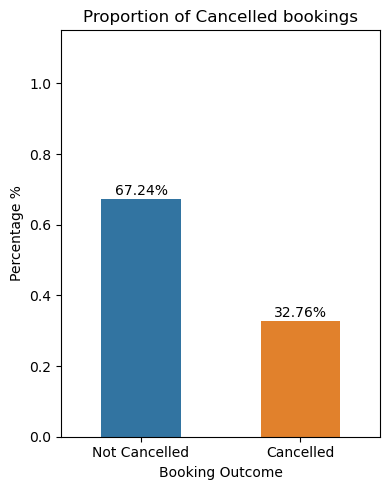

In [67]:
plt.figure(figsize = (4, 5))
ax = sns.barplot(df["booking_status"].value_counts(normalize = True).reset_index(), 
                 x = "booking_status", y = "proportion", hue = "booking_status",
                 width = 0.5)

for container in ax.containers:
    labels = [f"{v.get_height() * 100:.2f}%" for v in container]
    ax.bar_label(container, labels = labels, label_type = "edge", padding = 1)

plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])
plt.ylim(0, 1.15)

plt.title("Proportion of Cancelled bookings")
plt.xlabel("Booking Outcome")
plt.ylabel("Percentage %")

plt.tight_layout()
plt.show()

There is approximately a third (32.76%) of bookings cancelled and the other two-thirds (67.24%) of booking not cancelled. 

While not severly imbalanced, it is still important to consider balancing techniques, especially when predicting both classes during data modelling.

You can address it by:
- Oversampling
Increasing the number of cancelled bookings by duplicating to match the number of not cancelled bookings
- Undersampling
Randomly remove not cancelled bookings to match the number of cancelled bookings
-Subsampling
Create a balanced dataset by sampling an equal number of data from each class in `booking_status`.

### Analysing Number of Adults and Children in Bookings

Next, we analyse the distribution of booking patterns for the number of adults and children in hotel bookings. This is to observe the booking trends for the different group sizes for different age groups.

Note that we are removing observations for bookings made for more than 3 children, as there are only 3 observations for that. We want a more generalised idea of analysis.

In [68]:
print(f"There are {len(df.loc[df['no_of_children'] > 3, :])} bookings with more than 3 children.")

There are 3 bookings with more than 3 children.


In [69]:
no_of_guests_df = df.loc[df["no_of_children"] <= 3, ["no_of_adults", "no_of_children"]]
no_of_guests_df.head()

,no_of_adults,no_of_children
0,2,0
1,2,0
2,1,0
3,2,0
4,2,0


In [70]:
no_of_adult_series = no_of_guests_df["no_of_adults"].value_counts().sort_index()
no_of_children_series = no_of_guests_df["no_of_children"].value_counts().sort_index()

In [71]:
# To avoid displaying percentages on slices that are too small (less than 5%)
def display_pct(pct, series):
    return f"{pct:.1f}%" if pct >= 5 else ""

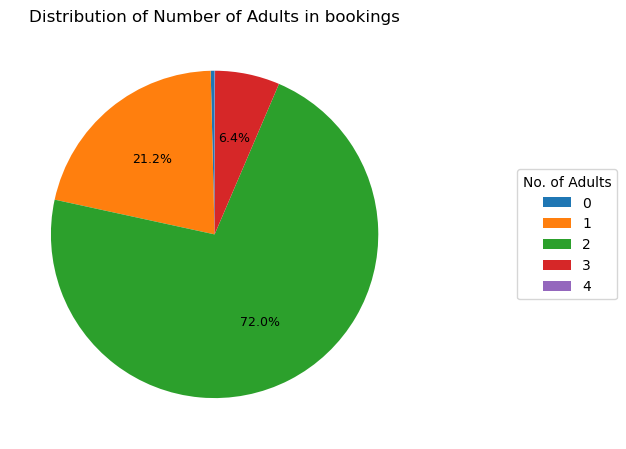

In [72]:
plt.figure(figsize = (7, 7))

plt.pie(no_of_adult_series, labels = None, startangle = 90, 
        autopct = lambda pct: display_pct(pct, no_of_adult_series), textprops = {"fontsize": 9})

plt.legend(no_of_adult_series.index, title = "No. of Adults", 
           loc = "center right", bbox_to_anchor = (1.5, 0.5))

plt.title("Distribution of Number of Adults in bookings")

plt.tight_layout()
plt.show()

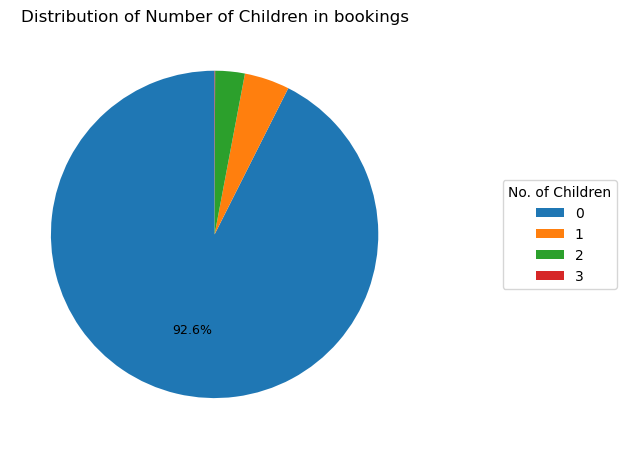

In [73]:
plt.figure(figsize = (7, 7))

plt.pie(no_of_children_series, labels = None, startangle = 90, 
        autopct = lambda pct: display_pct(pct, no_of_children_series), textprops = {"fontsize": 9})

plt.legend(no_of_children_series.index, title = "No. of Children", 
           loc = "center right", bbox_to_anchor = (1.5, 0.5))

plt.title("Distribution of Number of Children in bookings")

plt.tight_layout()
plt.show()

- For Adults

The maximum number of adults in a single booking is 4. Most bookings are made with 2 adults (72%), followed by adult (21%) and 3 adults (6%).

This suggests that many bookings are likely made by couples or families, where both parents are included in the reservation.

- For Children

The highest number of children in a booking is 3. Only about 8% of the bookings include at least one child, while the majority 92% are adult-only bookings.

This indicates that families with children make up a smaller portion of the overall bookings.

### Analysing Lead Time on Booking Cancellations

`lead_time` refers to the number of days between the booking date and check-in date. It explains how far in advance a guest made their reservation.

We analyse whether `lead_time` has a significant impact to the booking outcome - cancelled or not cancelled.

Using `pd.describe()`, we extract the statistic summary for `lead_time` based on the `booking_status`

In [74]:
lead_time_cancelled_series = df.loc[df["booking_status"] == "Cancelled", "lead_time"].describe().round(2)
lead_time_cancelled_dict = {
    "mean": lead_time_cancelled_series["mean"],
    "min": lead_time_cancelled_series["min"],
    "Q1": lead_time_cancelled_series["25%"],
    "median": lead_time_cancelled_series["50%"],
    "Q3": lead_time_cancelled_series["75%"],
    "top limit": 1.5 * (lead_time_cancelled_series["75%"] - lead_time_cancelled_series["25%"]) + lead_time_cancelled_series["75%"],
    "max": lead_time_cancelled_series["max"]
}

lead_time_cancelled_dict

{'mean': 139.22,
 'min': 0.0,
 'Q1': 55.0,
 'median': 122.0,
 'Q3': 205.0,
 'top limit': 430.0,
 'max': 443.0}

In [75]:
lead_time_not_cancelled_series = df.loc[df["booking_status"] == "Not_Cancelled", "lead_time"].describe().round(2)
lead_time_not_cancelled_dict = {
    "mean": lead_time_not_cancelled_series["mean"],
    "min": lead_time_not_cancelled_series["min"],
    "Q1": lead_time_not_cancelled_series["25%"],
    "median": lead_time_not_cancelled_series["50%"],
    "Q3": lead_time_not_cancelled_series["75%"],
    "top limit": 1.5 * (lead_time_not_cancelled_series["75%"] - lead_time_not_cancelled_series["25%"]) + lead_time_not_cancelled_series["75%"],
    "max": lead_time_not_cancelled_series["max"]
}

lead_time_not_cancelled_dict

{'mean': 58.93,
 'min': 0.0,
 'Q1': 10.0,
 'median': 39.0,
 'Q3': 86.0,
 'top limit': 200.0,
 'max': 386.0}

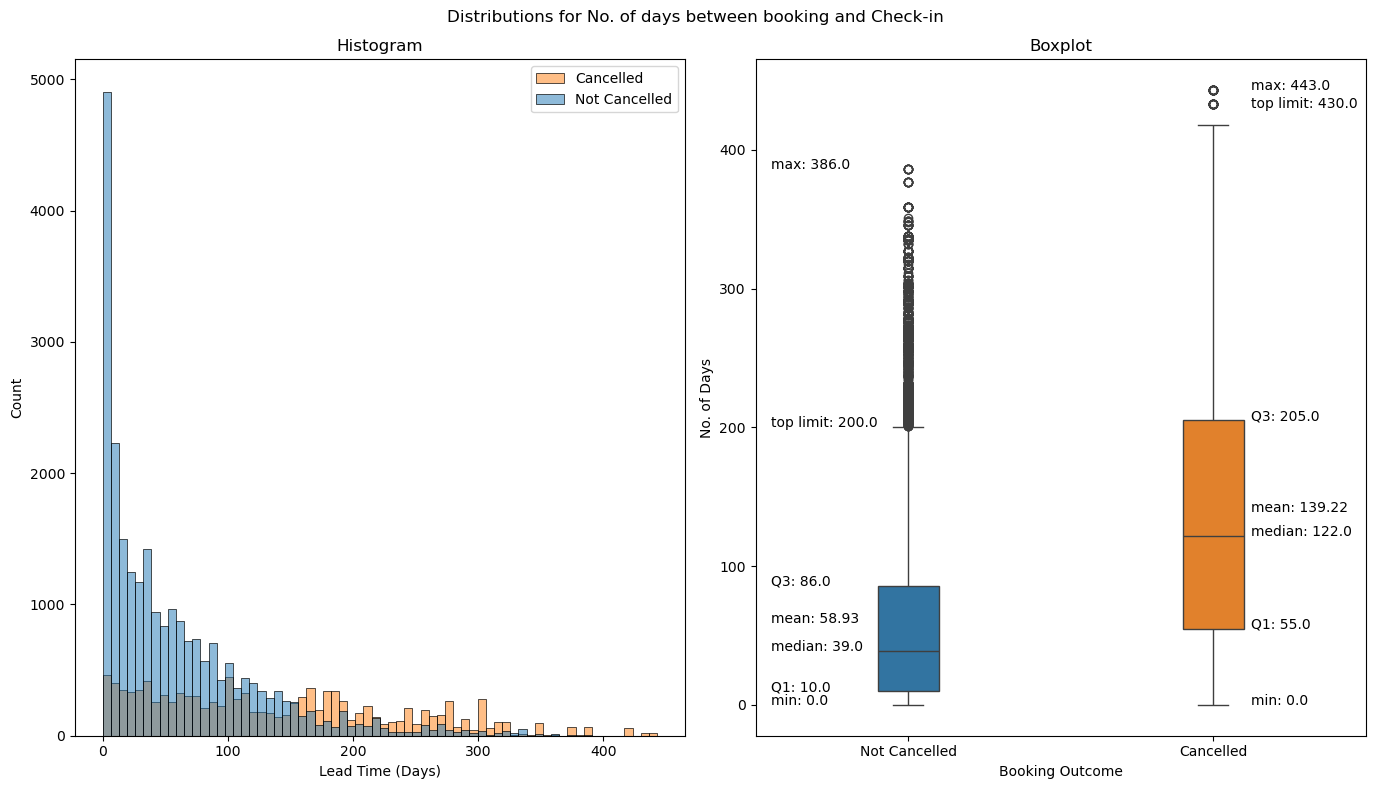

In [76]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (14, 8))
plt.suptitle("Distributions for No. of days between booking and Check-in")

sns.histplot(df, x = "lead_time", hue = "booking_status", ax = ax0)
sns.boxplot(df, x = "booking_status", y = "lead_time", width = 0.2, palette = ["#1f77b4", "#ff7f0e"], ax = ax1)
    
for stat, val in lead_time_not_cancelled_dict.items():
    ax1.text(-0.45, val, f"{stat}: {val}", fontsize = 10)

for stat, val in lead_time_cancelled_dict.items():
    ax1.text(1.125, val, f"{stat}: {val}", fontsize = 10)

ax0.legend(["Cancelled", "Not Cancelled"])
ax1.set_xticks([0, 1], ["Not Cancelled", "Cancelled"])

ax0.set_title("Histogram")
ax0.set_xlabel("Lead Time (Days)")
ax1.set_title("Boxplot")
ax1.set_xlabel("Booking Outcome")
ax1.set_ylabel("No. of Days")

plt.tight_layout()
plt.show()

There is a clear difference in booking behaviour when comparing `lead_times` between cancelled and not cancelled bookings.

The distribution of `lead_time` for not cancelled bookings is right-skewed, indicating that most guests who follow through their bookings tend to book closer to their check-in date.

Cancelled bookings show a more uniform distribution, suggesting that cancellations occur regardless of how far in advance the booking was made.

On average, cancelled bookings have a longer `lead_time` of 140 days, while not cancelled bookings have a shorter `lead_time` of 59 days.

Looking at the extremes, the upper whisker for cancelled bookings reaches 430 days, as compared to 200 days for not cancelled bookings. This shows that bookings made far in advance, especially those a year ahead, are more likely to be cancelled.

Bookings made closer to the check-in date are less likely to be cancelled, while longer `lead_time` are associated with a higher chance of booking cancellation.

### Analysing Number of Stayed Nights on Booking Cancellations

We analyse how the number of days booked affects the likelihood of booking cancellation. We want to identify whether stay durations (weekend and weekdays) are associated with higher cancellation rates.

Using `groupby()` on the number of nights and calculating the proportion of cancelled vs not cancelled bookings with `value_counts(normalize = True)`, we identify patterns in guest booking behaviour.

In [77]:
no_of_weekend_nights_df = df.groupby("no_of_weekend_nights")["booking_status"].value_counts(normalize = True).reset_index()
no_of_weekend_nights_df.head()

,no_of_weekend_nights,booking_status,proportion
0,0,Not_Cancelled,0.698139
1,0,Cancelled,0.301861
2,1,Not_Cancelled,0.656628
3,1,Cancelled,0.343372
4,2,Not_Cancelled,0.651968


In [78]:
no_of_week_nights_df = df.groupby("no_of_week_nights")["booking_status"].value_counts(normalize = True).reset_index()
no_of_week_nights_df.head()

,no_of_week_nights,booking_status,proportion
0,0,Not_Cancelled,0.715543
1,0,Cancelled,0.284457
2,1,Not_Cancelled,0.728921
3,1,Cancelled,0.271079
4,2,Not_Cancelled,0.650734


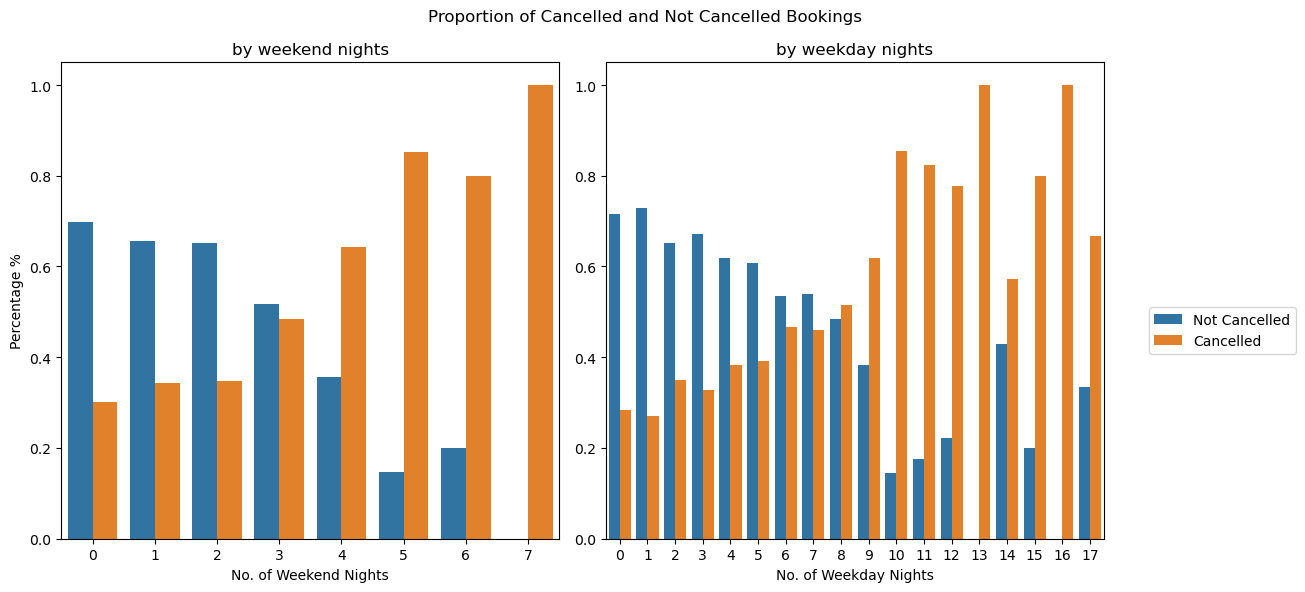

In [79]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (13, 6))

sns.barplot(no_of_weekend_nights_df, x = "no_of_weekend_nights", y = "proportion", hue = "booking_status", ax = ax0)
sns.barplot(no_of_week_nights_df, x = "no_of_week_nights", y = "proportion", hue = "booking_status", ax = ax1)

plt.suptitle("Proportion of Cancelled and Not Cancelled Bookings")

ax0.legend_.set_visible(False)
ax0.set_title("by weekend nights")
ax0.set_ylim(0, 1.05)
ax0.set_xlabel("No. of Weekend Nights")
ax0.set_ylabel("Percentage %")

handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ["Not Cancelled", "Cancelled"], loc = "upper right", bbox_to_anchor = (1.4, 0.5))
ax1.set_ylim(0, 1.05)
ax1.set_title("by weekday nights")
ax1.set_xlabel("No. of Weekday Nights")
ax1.set_ylabel("")

plt.tight_layout()
plt.show()

Note: Values are not displayed above the bars due to limited space.

We can see a positive correlation between the number of nights booked, both weekend and weekday nights, and cancellation rate. The longer the guest booked the stay, the higher likelihood the booking cancellation increases.

What if we look at the total number of nights booked? Will there be a difference?

In [80]:
no_of_total_nights_df = df.loc[:, ["no_of_weekend_nights", "no_of_week_nights", "booking_status"]]
no_of_total_nights_df["total"] = no_of_total_nights_df["no_of_weekend_nights"] + no_of_total_nights_df["no_of_week_nights"]

no_of_total_nights_df = no_of_total_nights_df.groupby("total")["booking_status"].value_counts(normalize = True).reset_index()
no_of_total_nights_df.head()

,total,booking_status,proportion
0,0,Not_Cancelled,0.974359
1,0,Cancelled,0.025641
2,1,Not_Cancelled,0.778013
3,1,Cancelled,0.221987
4,2,Not_Cancelled,0.657814


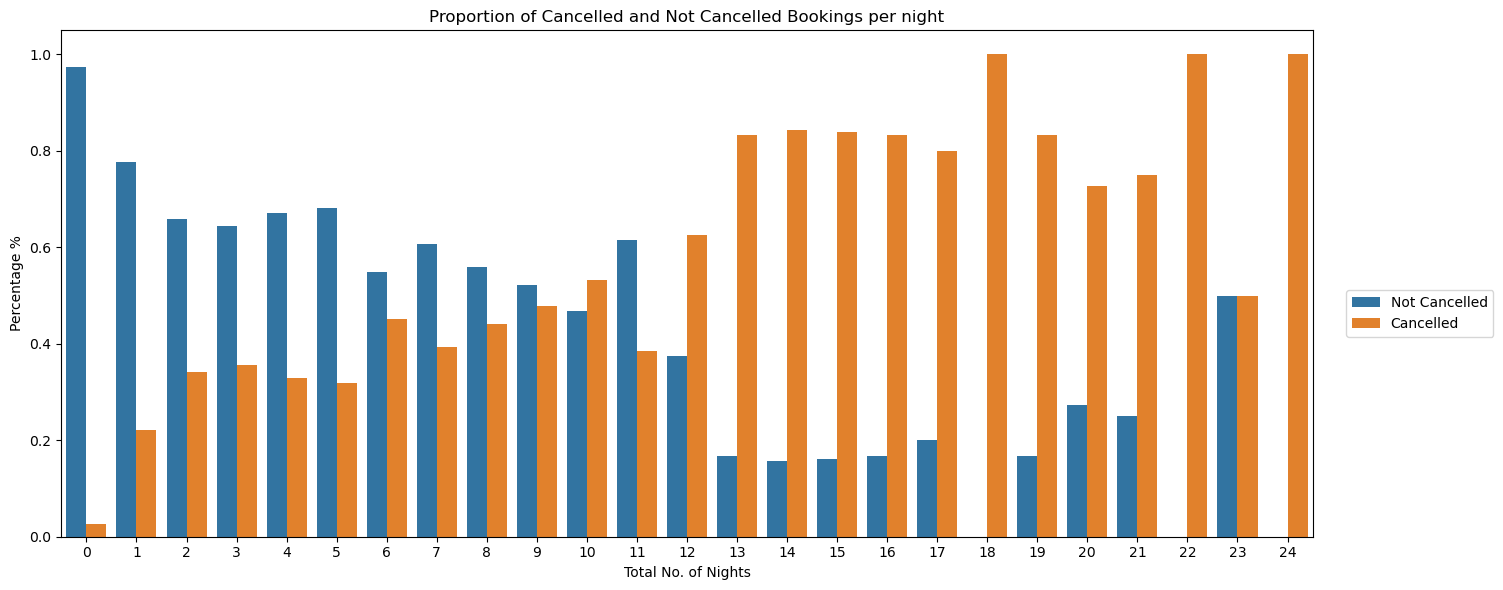

In [81]:
plt.figure(figsize = (15, 6))
ax = sns.barplot(no_of_total_nights_df, x = "total", y = "proportion", hue = "booking_status")

handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ["Not Cancelled", "Cancelled"], loc = "upper right", bbox_to_anchor = (1.15, 0.5))
plt.ylim(0, 1.05)
plt.title("Proportion of Cancelled and Not Cancelled Bookings per night")
plt.xlabel("Total No. of Nights")
plt.ylabel("Percentage %")

plt.tight_layout()
plt.show()

Note: Values are not displayed above the bars due to limited space.

As with earlier findings, we can see that bookings with short durations, typically around a week, are less likely to be cancelled. In contrast, longer bookings are more likely to be cancelled.

This suggests that guests planning for longer stays may be uncertain or prone to changing their plans. 

### Analysing Average Room Price and if Guest is a new Customer

As a booking can have multiple hotel rooms, we can analyse the average price per room in hotel bookings and compare it to whether the guest is a repeated customer. 

Lets see if repeated customers would spend more or less, or if the prices influence their likelihood of returning. Does this also have an impact on the booking outcome?

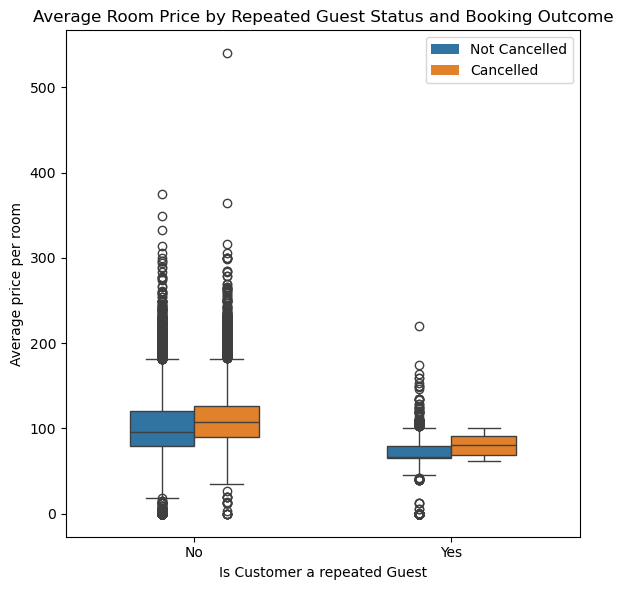

In [82]:
plt.figure(figsize = (6, 6))

sns.boxplot(df.loc[:, ["avg_price_per_room", "repeated_guest", "booking_status"]], 
            x = "repeated_guest", y = "avg_price_per_room", hue = "booking_status",
            width = 0.5)

plt.xticks([0, 1], ["No", "Yes"])

handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ["Not Cancelled", "Cancelled"])
plt.title("Average Room Price by Repeated Guest Status and Booking Outcome")
plt.xlabel("Is Customer a repeated Guest")
plt.ylabel("Average price per room")

plt.tight_layout()
plt.show()

Repeated guests tend to spend less on average per hotel room, as compared to new customers. The average price per room for new guests is around 100, while repeated guests typically pay below 100.

Interestingly, booking outcome (i.e cancelled or not cancelled) do not appear to differ significantly based on their repeated guest status. However, the range of room prices is noticeably wider for new customers, indicating more varying spending behaviour. Repeated customers show a narrower and more consistent price range.

Additionally, there is a trend suggesting that bookings with higher average room prices are more likely to be cancelled, possibilty due to higher financial requirement for booking.

### Analysing Average Room Price and if Guest made Special Requests

We analyse the relationship between average room prices and the number of special requests made by guests. 

Do the prices of room tend to increase when guests make more special requests? Are bookings with special requets less or more likely to be cancelled?

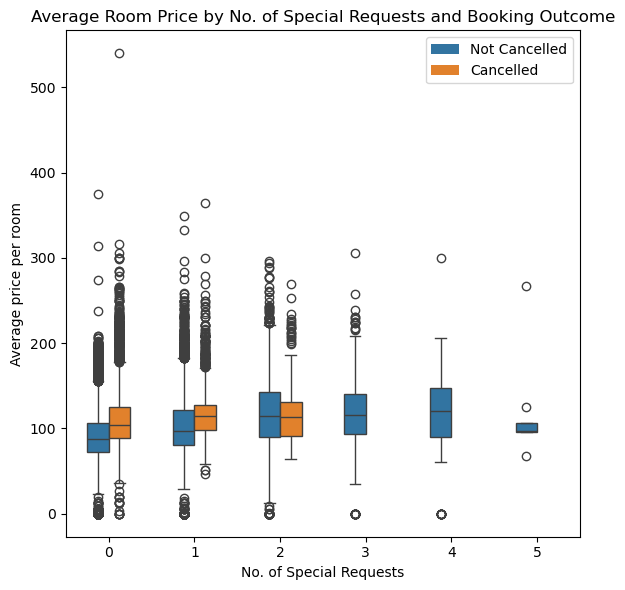

In [83]:
plt.figure(figsize = (6, 6))

sns.boxplot(df.loc[:, ["avg_price_per_room", "no_of_special_requests", "booking_status"]], 
            x = "no_of_special_requests", y = "avg_price_per_room", hue = "booking_status",
            width = 0.5)

handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ["Not Cancelled", "Cancelled"])
plt.title("Average Room Price by No. of Special Requests and Booking Outcome")
plt.xlabel("No. of Special Requests")
plt.ylabel("Average price per room")

plt.tight_layout()
plt.show()

The findings show that as the number of special requests increases, the likelihood of a booking being cancelled decreases. Specifically, bookings with three or more special requests had no cancellations at all, suggesting that guests who personalise their stay are more committed to following through their bookings.

For bookings with no special requests, the cancellation rate tends to be higher, especially for bookings with a higher average room price. Additionally, while the average price per room increases with the number of special requests, the difference in price is relatively small, indicating that guests are not paying significantly more for making additional requests.

This suggests that special requests for hotel bookings may be a slight indicator for booking intent.

---

## <a id = "sum_con">7. Summary and Conclusion<a/>

This report aims to explore and analyse the factors that influence hotel booking cancellations, with the goal of uncovering insights that could assist hotels in managing inventory, refining cancellation policies and improve forecasting strategies.

To begin, the dataset went through a cleaning process. Overall, the data was relatively cleaned and well-structured. Slight modifications were made for language consistency, by standardising spelling variations (cancelled and cancellation).

Exploratory Data Analysis was conducted to examine patterns and trend related to the target feature `booking_status`, which indicates whether a hotel booking was cancelled or not.

The analysis focused on guest composition, booking behaviour and room pricing. For example, longer lead times, extended stays, higher room prices and the absense of special requests are associated with higher cancellation rates. On the other hand, repeated guests and those who make special requests show greater booking commitment.

These insights can be valuable for hotels to develop target strategies, such as offering incentives for short stay or committed bookings, or tightening polices for long stay and high value bookings. Overall, the understanding and characteristics of booking cancellations can help improve overational efficiency, reduce revenue loss, and hopefully enhance guest satisfaction.

### Next Steps

To enhance the current analysis and prepare for Data Modelling, these are some improvements and extensions that can be considered:

- Refactoring Code for Reusability

The current code an benefit from the use of helper functions, especially for repeated tasks such as generating graph visualisations. This will help improve code readability, reduce redundancy, and make future updates easier to manage.
Additionally, implementing a verification algorithm for checking the validity between the number of weekend nights and weekday nights can help ensure data accuracy.

- More Feature Analysis

More in-depth exploration between features can be conducted. For example, bookings with no adults could be further investigated to see if the bookings are valid or potentially fradulent (e.g. fake bookings made by children).

There can also be analysis for market segments, such as examining which market tends to attract new customers, and whether those segments are associated with lower booking cancellation rates.

- Data Modelling

Although not the focus in this phase, future work could incorporate machine learning models to better understand the influence of various features on booking cancellations. This can provide a more practical approach to identifying key predictors, which could support a more accurate and strategic decision-making.

---

## <a id = "ref">8. References<a/>

1)	Raza A. (n.d.). Hotel Reservations Dataset. Kaggle. https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

---